# 🚀 NumPy Advanced Masterclass: Memory, Mathematics, and Broadcasting

## ⚡ 1. NumPy Arrays vs. Python Lists (Hardware & Memory Level)
Why exactly is NumPy so fast and memory-efficient? Let's look inside the RAM.

*   **Speed (CPU Vectorization):** A Python list is an array of pointers pointing to scattered objects in memory. To add two lists, the CPU must fetch each pointer, check object types, and calculate sequentially. NumPy stores raw binary data in a **contiguous block of memory**. It uses C-level libraries to apply SIMD (Single Instruction, Multiple Data), allowing the CPU to calculate multiple numbers simultaneously.
*   **Memory (RAM Allocation):** A standard Python integer object costs 28+ bytes because it contains metadata (reference counts, types). A NumPy `int8` array stores exactly 1 byte per number. No pointers, no metadata overhead.

In [129]:
import numpy as np
import time
import sys

# --- 1. SPEED TEST (10 Million items) ---
# Python List Approach
a_list = [i for i in range(10000000)]
b_list = [i for i in range(10000000, 20000000)]
c_list = []

start_list = time.time()
for i in range(len(a_list)):
    c_list.append(a_list[i] + b_list[i])
time_list = time.time() - start_list

# NumPy Vectorized Approach
a_arr = np.arange(10000000)
b_arr = np.arange(10000000, 20000000)

start_np = time.time()
c_arr = a_arr + b_arr
time_np = time.time() - start_np

print(f"Python List Time: {time_list:.4f} seconds")
print(f"NumPy Array Time: {time_np:.4f} seconds")
print(f"NumPy is ~{time_list/time_np:.1f}x faster!\n")

# --- 2. MEMORY TEST ---
list_mem = sys.getsizeof(a_list)
np_mem = sys.getsizeof(np.arange(10000000, dtype=np.int8))

print(f"Python List Memory: {list_mem / (1024**2):.2f} MB")
print(f"NumPy Array (int8): {np_mem / (1024**2):.2f} MB")

Python List Time: 1.8212 seconds
NumPy Array Time: 0.0371 seconds
NumPy is ~49.1x faster!

Python List Memory: 84.97 MB
NumPy Array (int8): 9.54 MB


## 🎯 2. Advanced Indexing
Standard slicing (`start:stop:step`) is great, but real-world data requires complex filtering.
*   **Fancy Indexing:** Passing a list/array of specific indices to extract non-sequential data.
*   **Boolean Indexing (Bit Masking):** Passing a conditional statement creates a hidden array of `True/False` (a mask). NumPy uses this mask to instantly filter elements at the C-level.

In [130]:
# Create a 6x4 matrix
a = np.random.randint(1, 100, 24).reshape(6, 4)
print("Original Array:\n", a)

# --- FANCY INDEXING ---
print("\nFancy Indexing (Rows 0, 2, 3, 5):")
print(a[[0, 2, 3, 5]])

print("\nFancy Indexing (All rows, specific columns 0, 2, 3):")
print(a[:, [0, 2, 3]])

# --- BOOLEAN INDEXING ---
print("\nNumbers > 50:\n", a[a > 50])
print("\nEven Numbers:\n", a[a % 2 == 0])

# Bitwise operators: & (AND), | (OR), ~ (NOT)
print("\nGreater than 50 AND Even:\n", a[(a > 50) & (a % 2 == 0)])
print("\nNot divisible by 7:\n", a[~(a % 7 == 0)])

Original Array:
 [[82 61 34 45]
 [21 89 63 90]
 [38 52 35 12]
 [32 59 43 21]
 [75  6  1  4]
 [ 6 14 10 85]]

Fancy Indexing (Rows 0, 2, 3, 5):
[[82 61 34 45]
 [38 52 35 12]
 [32 59 43 21]
 [ 6 14 10 85]]

Fancy Indexing (All rows, specific columns 0, 2, 3):
[[82 34 45]
 [21 63 90]
 [38 35 12]
 [32 43 21]
 [75  1  4]
 [ 6 10 85]]

Numbers > 50:
 [82 61 89 63 90 52 59 75 85]

Even Numbers:
 [82 34 90 38 52 12 32  6  4  6 14 10]

Greater than 50 AND Even:
 [82 90 52]

Not divisible by 7:
 [82 61 34 45 89 90 38 52 12 32 59 43 75  6  1  4  6 10 85]


## 📡 3. Broadcasting (The Magic Concept)
Broadcasting is NumPy's way of doing math on arrays of completely different shapes. 
**Memory Reality:** When a smaller array is "broadcast" (stretched) to match a larger array, NumPy **does not actually copy the data in RAM**. It simply adjusts the *Strides* (memory steps) to read the same smaller array over and over again. This saves massive amounts of memory.

### 🛑 The 2 Strict Rules of Broadcasting:
1.  **Alignment:** Align shapes from right to left (trailing dimensions first).
2.  **Compatibility:** Two dimensions are compatible if:
    *   They are exactly equal, OR
    *   One of them is `1`. (The `1` gets stretched to match the other).

### Broadcasting

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is “broadcast” across the larger array so that they have compatible shapes.

In [131]:
# --- Broadcasting Examples ---

# Example 1: (4, 3) + (3,) 
# Shape 1:  4 x 3
# Shape 2:      3  (Matches exactly, gets stretched to 4x3)
a = np.arange(12).reshape(4, 3)
b = np.arange(3)
print("Example 1 Result:\n", a + b)

# Example 2: (1, 3) + (4, 1)
# Shape 1:  1 x 3  (Row stretches to 4)
# Shape 2:  4 x 1  (Column stretches to 3)
# Result:   4 x 3
a = np.arange(3).reshape(1, 3)
b = np.arange(4).reshape(4, 1)
print("\nExample 2 Result:\n", a + b)

# Example 3: FAILURE CASE -> (16,) shaped to (4, 4) + (2, 2)
# Shape 1:  4 x 4
# Shape 2:  2 x 2
# Fails because 4 != 2 and neither is 1.
try:
    a = np.arange(16).reshape(4, 4)
    b = np.arange(4).reshape(2, 2)
    a + b
except ValueError as e:
    print("\nExample 3 Failed as expected:", e)

Example 1 Result:
 [[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]

Example 2 Result:
 [[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]

Example 3 Failed as expected: operands could not be broadcast together with shapes (4,4) (2,2) 


#### Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**<br>
- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.<br>

**2. Make each dimension of the two arrays the same size.**<br>
- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

<img src = "https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png">

## 🧮 4. Mathematical Formulas & Missing Values
NumPy allows you to write complex math formulas exactly as they appear on paper. Because of Vectorization, these formulas are applied to millions of data points instantly.

We also handle missing data using `np.nan` (Not a Number), which is highly crucial in Data Science cleaning pipelines.

In [ ]:
# --- 1. Sigmoid Activation Function (Used in Neural Networks) ---
def sigmoid(array):
    return 1 / (1 + np.exp(-array))

a = np.arange(-5, 5)
print("Sigmoid output:\n", sigmoid(a))

# --- 2. Mean Squared Error (Loss function in Machine Learning) ---
actual = np.random.randint(1, 50, 25)
predicted = np.random.randint(1, 50, 25)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

print("\nMean Squared Error:", mse(actual, predicted))

# --- 3. Handling Missing Values ---
arr_with_nan = np.array([1, 2, 3, 4, np.nan, 6])
print("\nOriginal array with missing value:\n", arr_with_nan)

# Boolean masking to filter out np.nan
clean_arr = arr_with_nan[~np.isnan(arr_with_nan)]
print("Cleaned array (np.nan removed):\n", clean_arr)

In [108]:
# binary cross entropy
# Home work

## 📈 5. Visualizing Math (Basic Matplotlib)
By generating arrays with `np.linspace`, we can easily plot simple mathematical functions.

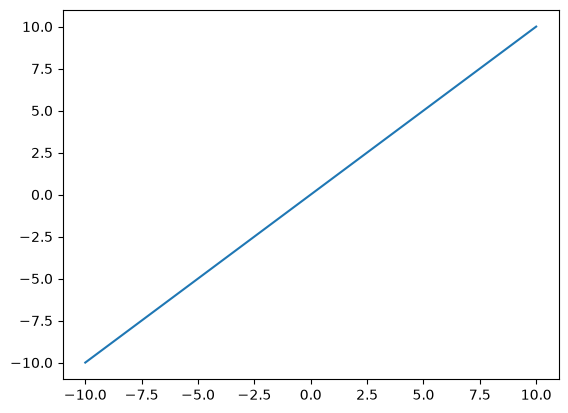

In [132]:
import matplotlib.pyplot as plt
import numpy as np

# 1. y = x (Linear)
x = np.linspace(-10, 10, 100)
y = x
plt.plot(x, y)
plt.show()

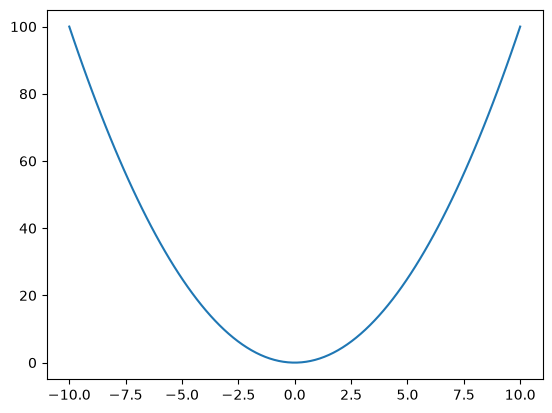

In [133]:
# 2. y = x^2 (Quadratic)
x = np.linspace(-10, 10, 100)
y = x**2
plt.plot(x, y)
plt.show()

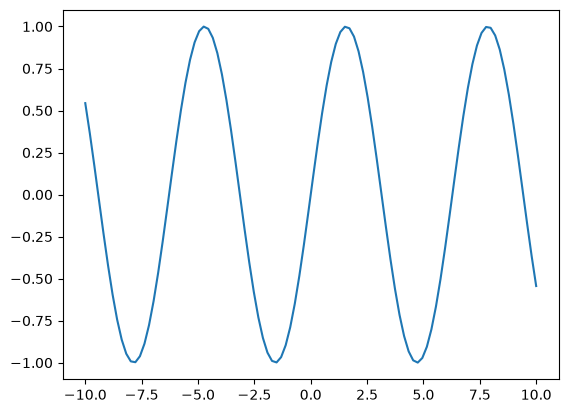

In [134]:
# 3. y = sin(x) (Trigonometric)
x = np.linspace(-10, 10, 100)
y = np.sin(x)
plt.plot(x, y)
plt.show()

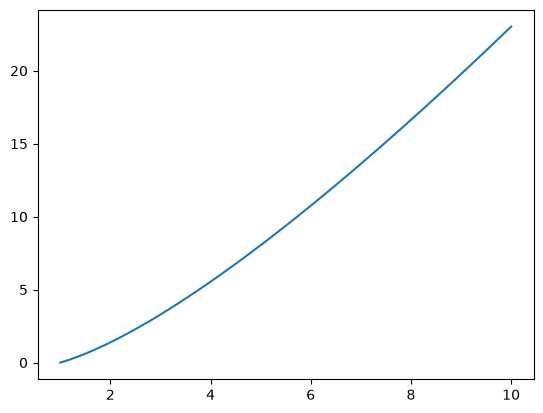

In [135]:
# 4. y = x * log(x)
# Note: log of negative numbers will throw a runtime warning, 
# so it's better to start linspace from a positive number like 1.
x = np.linspace(1, 10, 100) 
y = x * np.log(x)
plt.plot(x, y)
plt.show()

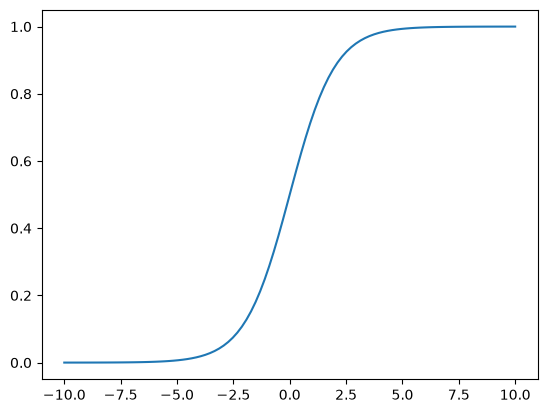

In [136]:
# 5. Sigmoid Function
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))
plt.plot(x, y)
plt.show()